# Assignment 2.2 — streaming demo

For this demo I used the white wine csv from assignment 2.1 and trained models chunk by chunk (like data is still arriving) instead of loading everything at once.

I built two pipelines — one with a single decision tree, one with bagging — and used StreamTrainer to partial_fit each chunk and log accuracy. After training I also check streaming metrics (confusion matrix, precision, recall, f1) and plot accuracy over chunks.

## Setup

First cell adds NumCompute to the path so imports work when you open the notebook from demo/ (I kept getting ModuleNotFoundError without this). It also clears any cached numcompute_stream imports — if you still get ImportError after editing the package, restart the kernel and run from the top.

If you prefer you can pip install -e .. from the NumCompute folder instead and skip the path hack.

In [50]:
import sys
from pathlib import Path

import numpy as np

%matplotlib inline


def _find_package_root():
    # notebook is usually run from NumCompute/demo/
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent / "NumCompute",
    ]
    for path in candidates:
        if (path / "numcompute").is_dir() and (path / "numcompute_stream").is_dir():
            return path.resolve()
    raise ImportError(
        "Could not find numcompute. cd to NumCompute/demo or run: pip install -e .."
    )


root = _find_package_root()
root_str = str(root)
if root_str in sys.path:
    sys.path.remove(root_str)
sys.path.insert(0, root_str)

# drop cached numcompute_stream modules so re-running setup picks up code changes
for mod_name in list(sys.modules):
    if mod_name == "numcompute_stream" or mod_name.startswith("numcompute_stream."):
        del sys.modules[mod_name]

from numcompute.io import load_csv
from numcompute_stream.ensemble import BaggingClassifier
from numcompute_stream.metrics import (
    RollingWindowAccuracy,
    RollingWindowF1,
    StreamingAUC,
    StreamingConfusionMatrix,
    StreamingF1,
    StreamingPrecision,
    StreamingRecall,
)
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.preprocessing import StandardScaler
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.visualise import (
    compare_models,
    plot_metric_over_time,
    plot_predictions_vs_ground_truth,
)

np.set_printoptions(linewidth=120, precision=4, suppress=True)
print("using package root:", root)

using package root: /Users/megatunger/Github/numpy-compute/NumCompute


## 1. Load data

Same wine file as before — 11 input columns and quality in the last column.

I turned quality into a binary label: **1** if quality >= 6 (good enough), **0** otherwise, so the tree can do classification.

In [51]:
wine = load_csv("../assets/winequality-white.csv", dtype=np.float32, delimiter=";")
print("raw shape:", wine.shape)

X = wine[:, :11]
y = (wine[:, 11] >= 6).astype(int)

print("X shape:", X.shape)
print("class balance (0, 1):", np.bincount(y))

raw shape: (4898, 12)
X shape: (4898, 11)
class balance (0, 1): [1640 3258]


## 2. Split into chunks

I cut the dataset into batches of 50 rows. Each batch is one chunk that arrives later — that's what partial_fit is for in our streaming package.

In [52]:
chunk_size = 50
chunks = [
    (X[i:i + chunk_size], y[i:i + chunk_size])
    for i in range(0, len(X), chunk_size)
]

print(f"{len(chunks)} chunks of up to {chunk_size} rows")
print("first chunk shapes:", chunks[0][0].shape, chunks[0][1].shape)

98 chunks of up to 50 rows
first chunk shapes: (50, 11) (50,)


## 3. Build pipelines

Both pipelines scale features first (StandardScaler with partial_fit), then a model.

- pipe_tree — one decision tree, max_depth=5
- pipe_bagging — bagging with 5 trees (same depth), random_state=42 so runs are repeatable

In [53]:
pipe_tree = Pipeline([
    ("scale", StandardScaler()),
    ("model", DecisionTreeClassifier(max_depth=5, min_samples_split=2)),
])

pipe_bagging = Pipeline([
    ("scale", StandardScaler()),
    ("model", BaggingClassifier(n_estimators=5, max_depth=5, random_state=42)),
])

## 4. Train incrementally

Loop over every chunk and call fit_chunk on both trainers. That partial_fits the pipeline, predicts on the same chunk, and appends to log_ (chunk accuracy, cumulative accuracy, etc.).

I print tree vs bagging accuracy each chunk so you can see them improve as more data comes in.

In [54]:
trainer_tree = StreamTrainer(pipe_tree)
trainer_bagging = StreamTrainer(pipe_bagging)

tree_accuracies = []
bagging_accuracies = []

for i, (X_chunk, y_chunk) in enumerate(chunks):
    trainer_tree.fit_chunk(X_chunk, y_chunk)
    trainer_bagging.fit_chunk(X_chunk, y_chunk)

    tree_acc = trainer_tree.log_[-1]["chunk_accuracy"]
    bagging_acc = trainer_bagging.log_[-1]["chunk_accuracy"]
    tree_accuracies.append(tree_acc)
    bagging_accuracies.append(bagging_acc)

    print(
        f"chunk {i + 1:2d}/{len(chunks)} | "
        f"tree={tree_acc:.3f} | bagging={bagging_acc:.3f}"
    )

chunk  1/98 | tree=1.000 | bagging=0.940
chunk  2/98 | tree=0.980 | bagging=0.880
chunk  3/98 | tree=0.720 | bagging=0.720
chunk  4/98 | tree=0.580 | bagging=0.620
chunk  5/98 | tree=0.620 | bagging=0.620
chunk  6/98 | tree=0.740 | bagging=0.700
chunk  7/98 | tree=0.620 | bagging=0.740
chunk  8/98 | tree=0.840 | bagging=0.800
chunk  9/98 | tree=0.680 | bagging=0.660
chunk 10/98 | tree=0.720 | bagging=0.640
chunk 11/98 | tree=0.740 | bagging=0.740
chunk 12/98 | tree=0.740 | bagging=0.800
chunk 13/98 | tree=0.740 | bagging=0.580
chunk 14/98 | tree=0.620 | bagging=0.600
chunk 15/98 | tree=0.800 | bagging=0.660
chunk 16/98 | tree=0.900 | bagging=0.840
chunk 17/98 | tree=0.780 | bagging=0.740
chunk 18/98 | tree=0.700 | bagging=0.780
chunk 19/98 | tree=0.580 | bagging=0.580
chunk 20/98 | tree=0.720 | bagging=0.780
chunk 21/98 | tree=0.660 | bagging=0.720
chunk 22/98 | tree=0.640 | bagging=0.700
chunk 23/98 | tree=0.520 | bagging=0.640
chunk 24/98 | tree=0.720 | bagging=0.640
chunk 25/98 | tr

## 5. Streaming metrics

After all chunks are trained, I loop once more on the bagging model and feed every chunk into the streaming metric classes. They build up counts the same way as in the tests.

This also checks the newer AUC and rolling-window metrics. The rolling metrics only use the latest 200 samples, so they show recent performance instead of the full stream.

In [55]:
cm = StreamingConfusionMatrix()
precision = StreamingPrecision(pos_label=1)
recall = StreamingRecall(pos_label=1)
f1 = StreamingF1(pos_label=1)
auc = StreamingAUC(pos_label=1)
rolling_acc = RollingWindowAccuracy(window_size=200)
rolling_f1 = RollingWindowF1(window_size=200)

for X_chunk, y_chunk in chunks:
    y_pred = pipe_bagging.predict(X_chunk)
    cm.update(y_chunk, y_pred)
    precision.update(y_chunk, y_pred)
    recall.update(y_chunk, y_pred)
    f1.update(y_chunk, y_pred)
    auc.update(y_chunk, y_pred)
    rolling_acc.update(y_chunk, y_pred)
    rolling_f1.update(y_chunk, y_pred)

print("confusion matrix (bagging, all chunks):")
print(cm.result())
print("precision:", round(precision.result(), 3))
print("recall:", round(recall.result(), 3))
print("f1:", round(f1.result(), 3))
print("auc:", round(auc.result(), 3))
print("rolling accuracy (last 200):", round(rolling_acc.result(), 3))
print("rolling f1 (last 200):", round(rolling_f1.result(), 3))

confusion matrix (bagging, all chunks):
[[ 280. 1360.]
 [ 139. 3119.]]
precision: 0.957
recall: 0.696
f1: 0.806
auc: 0.564
rolling accuracy (last 200): 0.775
rolling f1 (last 200): 0.868


## 6. Plots

Using the visualise module I wrote for the assignment — line plot for the tree, side-by-side comparison with bagging, and a scatter of predictions vs labels on the last chunk (bagging model).

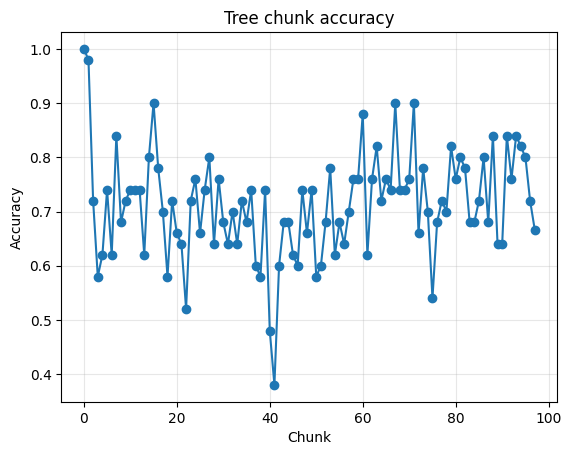

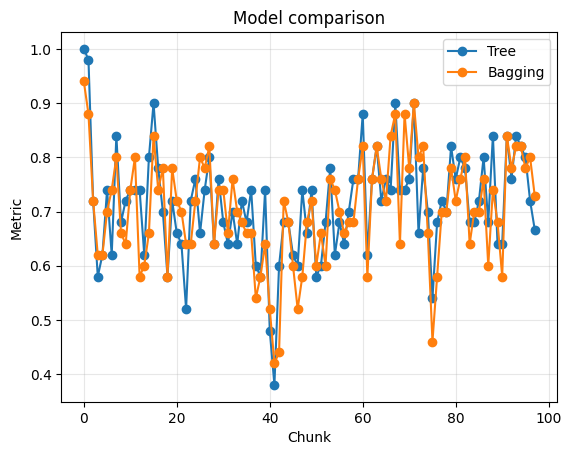

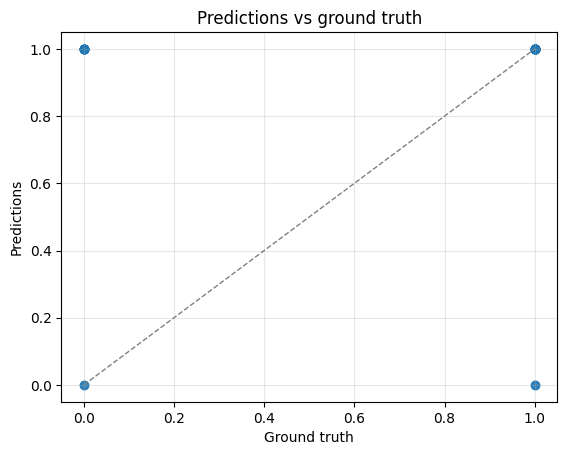

In [56]:
plot_metric_over_time(tree_accuracies, "Tree chunk accuracy", "Accuracy")
compare_models(tree_accuracies, bagging_accuracies, ["Tree", "Bagging"])

X_last, y_last = chunks[-1]
y_pred_last = pipe_bagging.predict(X_last)
plot_predictions_vs_ground_truth(y_last, y_pred_last)

## 7. Summary

Quick numbers at the end — how many chunks we trained on and final cumulative accuracy for both models.

In [57]:
print(f"chunks trained: {len(chunks)}")
print(f"tree cumulative accuracy: {trainer_tree.log_[-1]['cumulative_accuracy']:.3f}")
print(f"bagging cumulative accuracy: {trainer_bagging.log_[-1]['cumulative_accuracy']:.3f}")
print(f"tree scaler mean (first 3 features): {pipe_tree.named_steps['scale'].mean_[:3]}")

chunks trained: 98
tree cumulative accuracy: 0.713
bagging cumulative accuracy: 0.705
tree scaler mean (first 3 features): [6.8548 0.2782 0.3342]
